M1-M3 are the assumed models. M1-M7 are observation data-generating processes.

In [29]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd

sd.quiet_bayesflow_progress()

In [30]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 100
num_datasets = 50
num_samples = 1000
n_ref = 2000

project_dir = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_dir = project_dir / "results" / "m1_m7_ood"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    
    "m4": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m5": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 2.0},
    "m7": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 3.0},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
pd.DataFrame(source_specs).T

,mu_prior_mean,mu_prior_std,likelihood_std
m1,0.0,1.0,1.0
m2,3.0,1.0,1.0
m3,0.0,1.0,3.0
m4,1.5,1.0,1.0
m5,5.0,1.0,1.0
m6,0.0,1.0,5.0
m7,1.5,1.0,3.0


In [31]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [32]:
# generate test datasets
datasets = {}
for source, spec in source_specs.items():
    data = GetDatasets(
        obs_mu_prior_mean=spec["mu_prior_mean"],
        obs_mu_prior_std=spec["mu_prior_std"],
        num_dims=num_dims,
        num_obs=num_obs,
        obs_likelihood_std=spec["likelihood_std"],
        num_datasets=num_datasets,
        rng=RNG,
    ).get_datasets_normal()
    for item in data:
        item["source_model"] = source
    datasets[source] = data
    save_pickle(data, dataset_dir / f"{source}_raw.pkl") # save datasets seprately for each source model

print(datasets["m1"][0].keys())

dict_keys(['mu', 'x', 'id', 'source_model'])


In [33]:
datasets = {source: load_pickle(dataset_dir / f"{source}_raw.pkl") for source in sd.SOURCE_MODELS}

In [34]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_20d_100n.keras"
filepath_m2 = network_dir / "m2_s_20d_100n.keras"
filepath_m3 = network_dir / "m3_s_20d_100n.keras"
filepath_direct = network_dir / "direct_s_20d_100n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3}

In [35]:
# Compute logmls and PMPs
calculation_m1 = Calculation(
    approximator=approximator_m1,
    mu_prior_mean=0.0,
    mu_prior_std=1.0,
    num_dims=num_dims,
    num_obs=num_obs,
    likelihood_std=1.0,
    num_samples=num_samples,
    assumed_model="m1",
)
calculation_m2 = Calculation(
    approximator=approximator_m2,
    mu_prior_mean=3.0,
    mu_prior_std=1.0,
    num_dims=num_dims,
    num_obs=num_obs,
    likelihood_std=1.0,
    num_samples=num_samples,
    assumed_model="m2",
)
calculation_m3 = Calculation(
    approximator=approximator_m3,
    mu_prior_mean=0.0,
    mu_prior_std=1.0,
    num_dims=num_dims,
    num_obs=num_obs,
    likelihood_std=3.0,
    num_samples=num_samples,
    assumed_model="m3",
)

calculations = {"m1": calculation_m1, "m2": calculation_m2, "m3": calculation_m3}

In [36]:
datasets = sd.compute_logml_and_posteriors(datasets, calculations)
datasets = sd.compute_model_probabilities(datasets, approximator_direct)

for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_logml_pmp.pkl")

print(datasets["m1"][0].keys())

dict_keys(['mu', 'x', 'id', 'source_model', 'gold_log_marginal_m1', 'gold_post_samples_m1', 'npe_post_samples_m1', 'npe_log_marginal_m1', 'npe_log_marginal_gp_m1', 'gold_log_marginal_m2', 'gold_post_samples_m2', 'npe_post_samples_m2', 'npe_log_marginal_m2', 'npe_log_marginal_gp_m2', 'gold_log_marginal_m3', 'gold_post_samples_m3', 'npe_post_samples_m3', 'npe_log_marginal_m3', 'npe_log_marginal_gp_m3', 'p_direct', 'logBF_12_direct', 'logBF_13_direct', 'logBF_23_direct', 'logBF_12_gold', 'logBF_13_gold', 'logBF_23_gold', 'logBF_12_npe', 'logBF_13_npe', 'logBF_23_npe', 'p_gold', 'p_npe'])


In [37]:
# Fit summary-space reference distributions
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS)
}
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref)
pd.DataFrame({k: {"dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,dm_low,dm_high,median
m1,6.971847,13.404508,9.262089
m2,7.055973,13.585885,9.451626
m3,7.147192,14.637374,9.874251


In [38]:
# Add dynamic distance regimes and ambiguity score
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
logml_df.to_csv(result_dir / "logml_distance_frame.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed.pkl")

display(logml_summary.round(3))
display(pmp_summary.round(3))

,assumed_model,source_model,distance_regime,n,median_d_M,median_signed_logml_error
0,m1,m1,in_distribution,44,9.293,-0.011
1,m2,m1,extrapolation,50,43.666,-142.588
2,m3,m1,extrapolation,50,27.452,-88.646
3,m1,m1,interpolation,2,6.580,0.001
4,m1,m1,extrapolation,4,14.015,0.058
5,m1,m2,extrapolation,50,37.468,-152.665
6,m2,m2,in_distribution,45,9.985,0.013
7,m3,m2,extrapolation,50,40.907,-2.975
8,m2,m2,extrapolation,4,13.911,0.012
9,m2,m2,interpolation,1,6.971,0.044


,source_model,at_least_one_not_extrapolative,n,median_d_min,median_A,median_pmp_l1_error_npe
0,m1,True,46,9.263,0.000,0.0
1,m1,False,4,14.015,0.061,0.0
2,m2,True,46,9.982,0.000,0.0
3,m2,False,4,13.911,0.049,0.0
4,m3,True,49,9.794,0.000,0.0
5,m3,False,1,18.317,0.061,0.0
6,m4,False,48,16.880,0.197,0.0
7,m4,True,2,13.015,0.000,0.0
8,m5,False,50,27.604,0.056,0.0
9,m6,True,36,13.206,0.000,0.0


In [39]:
print(len(logml_summary))

31


In [40]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed.pkl") for source in sd.SOURCE_MODELS}
logml_df = pd.read_csv(result_dir / "logml_distance_frame.csv")
pmp_df = pd.read_csv(result_dir / "pmp_ambiguity_frame.csv")

In [41]:
print(pmp_df.columns)

Index(['source_model', 'id', 'globally_extrapolative',
       'at_least_one_not_extrapolative', 'not_extrapolative_count',
       'ambiguity_score', 'd_min', 'd_second', 'closest_summary_models',
       'pmp_l1_error_npe', 'pmp_l1_error_direct', 'extrapolation_class',
       'nearest_two_extrapolation_class', 'd_m1', 'dm_low_m1', 'dm_high_m1',
       'regime_m1', 'p_gold_m1', 'p_npe_m1', 'p_direct_m1',
       'signed_pmp_error_npe_m1', 'signed_pmp_error_direct_m1', 'd_m2',
       'dm_low_m2', 'dm_high_m2', 'regime_m2', 'p_gold_m2', 'p_npe_m2',
       'p_direct_m2', 'signed_pmp_error_npe_m2', 'signed_pmp_error_direct_m2',
       'd_m3', 'dm_low_m3', 'dm_high_m3', 'regime_m3', 'p_gold_m3', 'p_npe_m3',
       'p_direct_m3', 'signed_pmp_error_npe_m3', 'signed_pmp_error_direct_m3'],
      dtype='object')


## Signed logml error plots

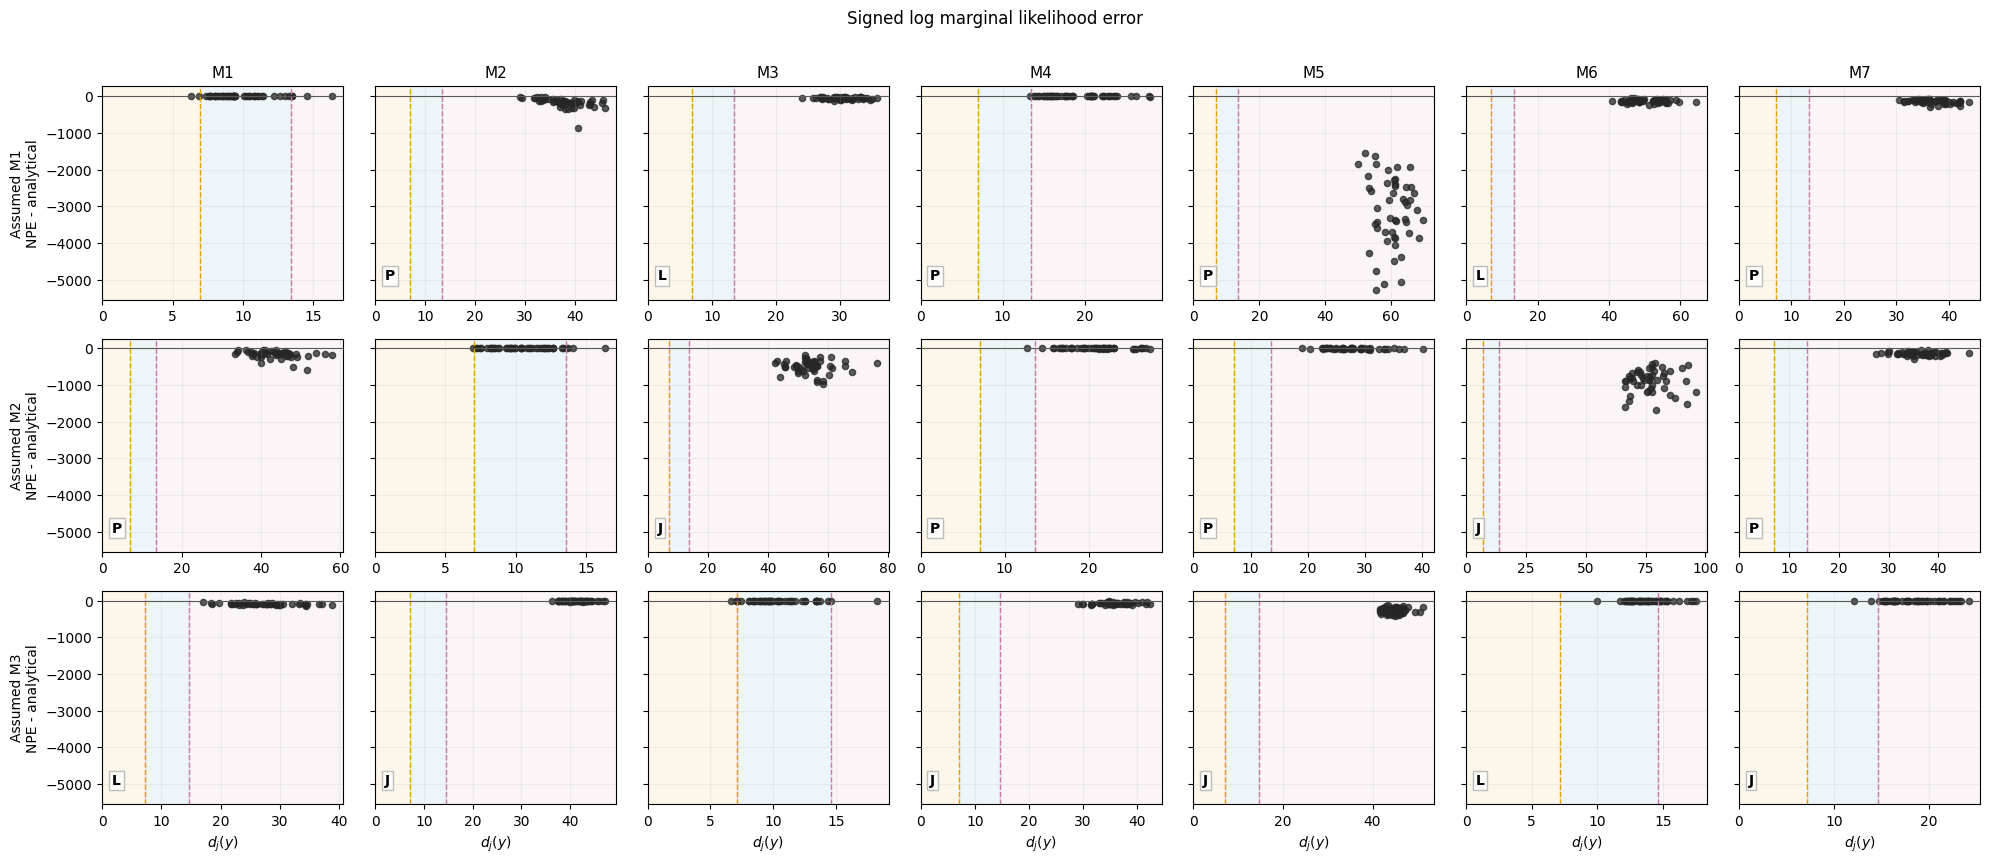

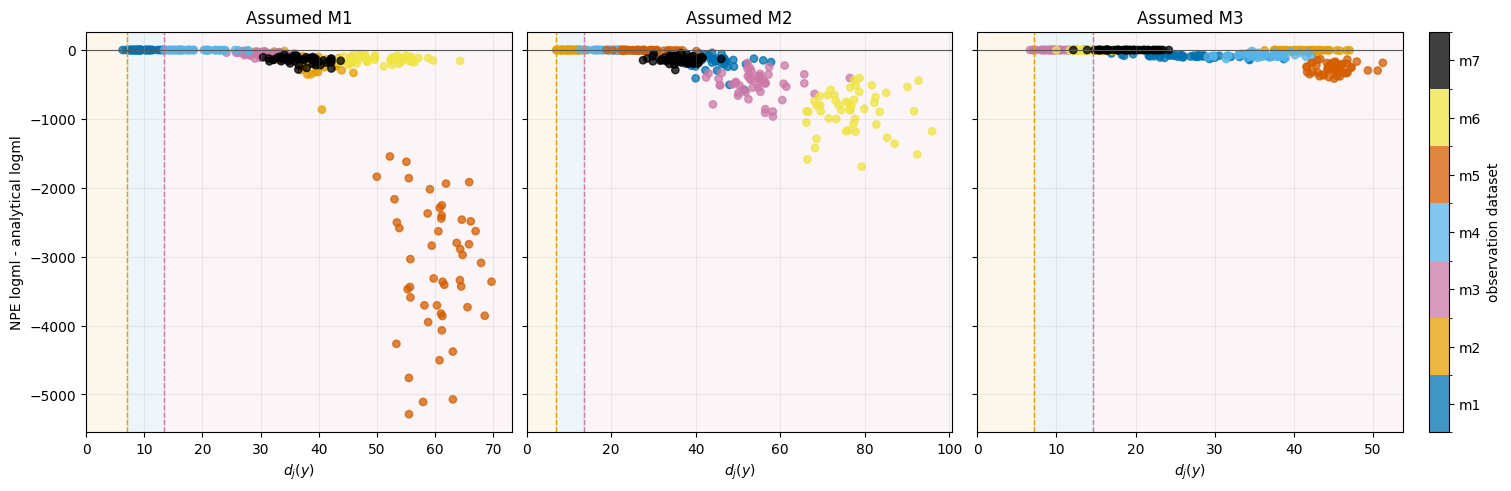

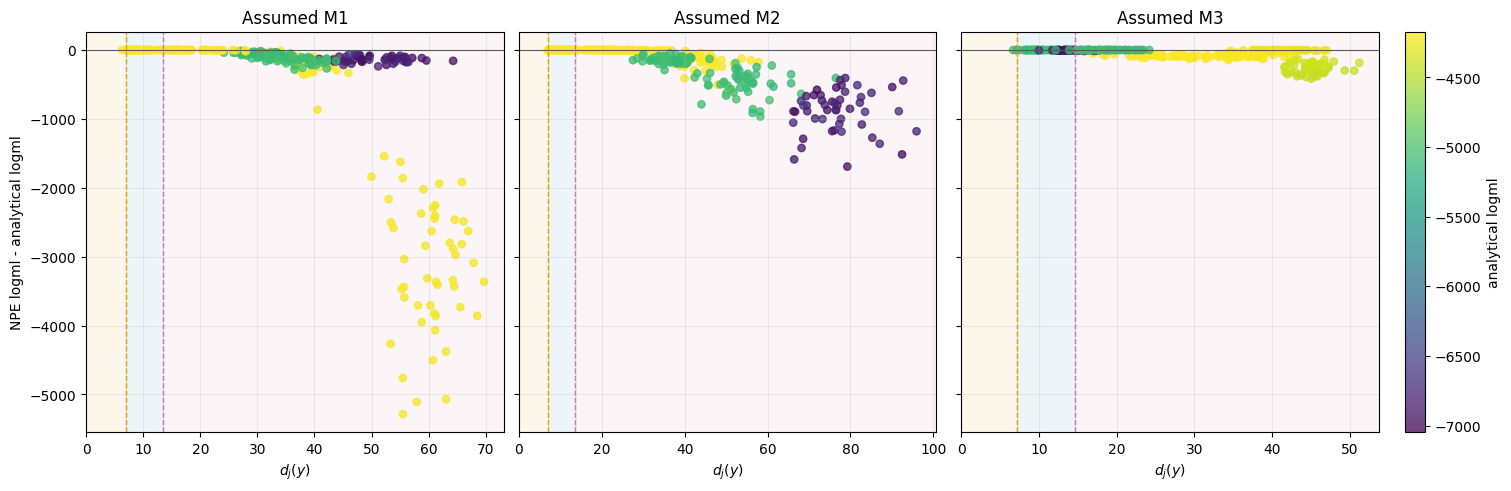

In [42]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir);
sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir);
sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

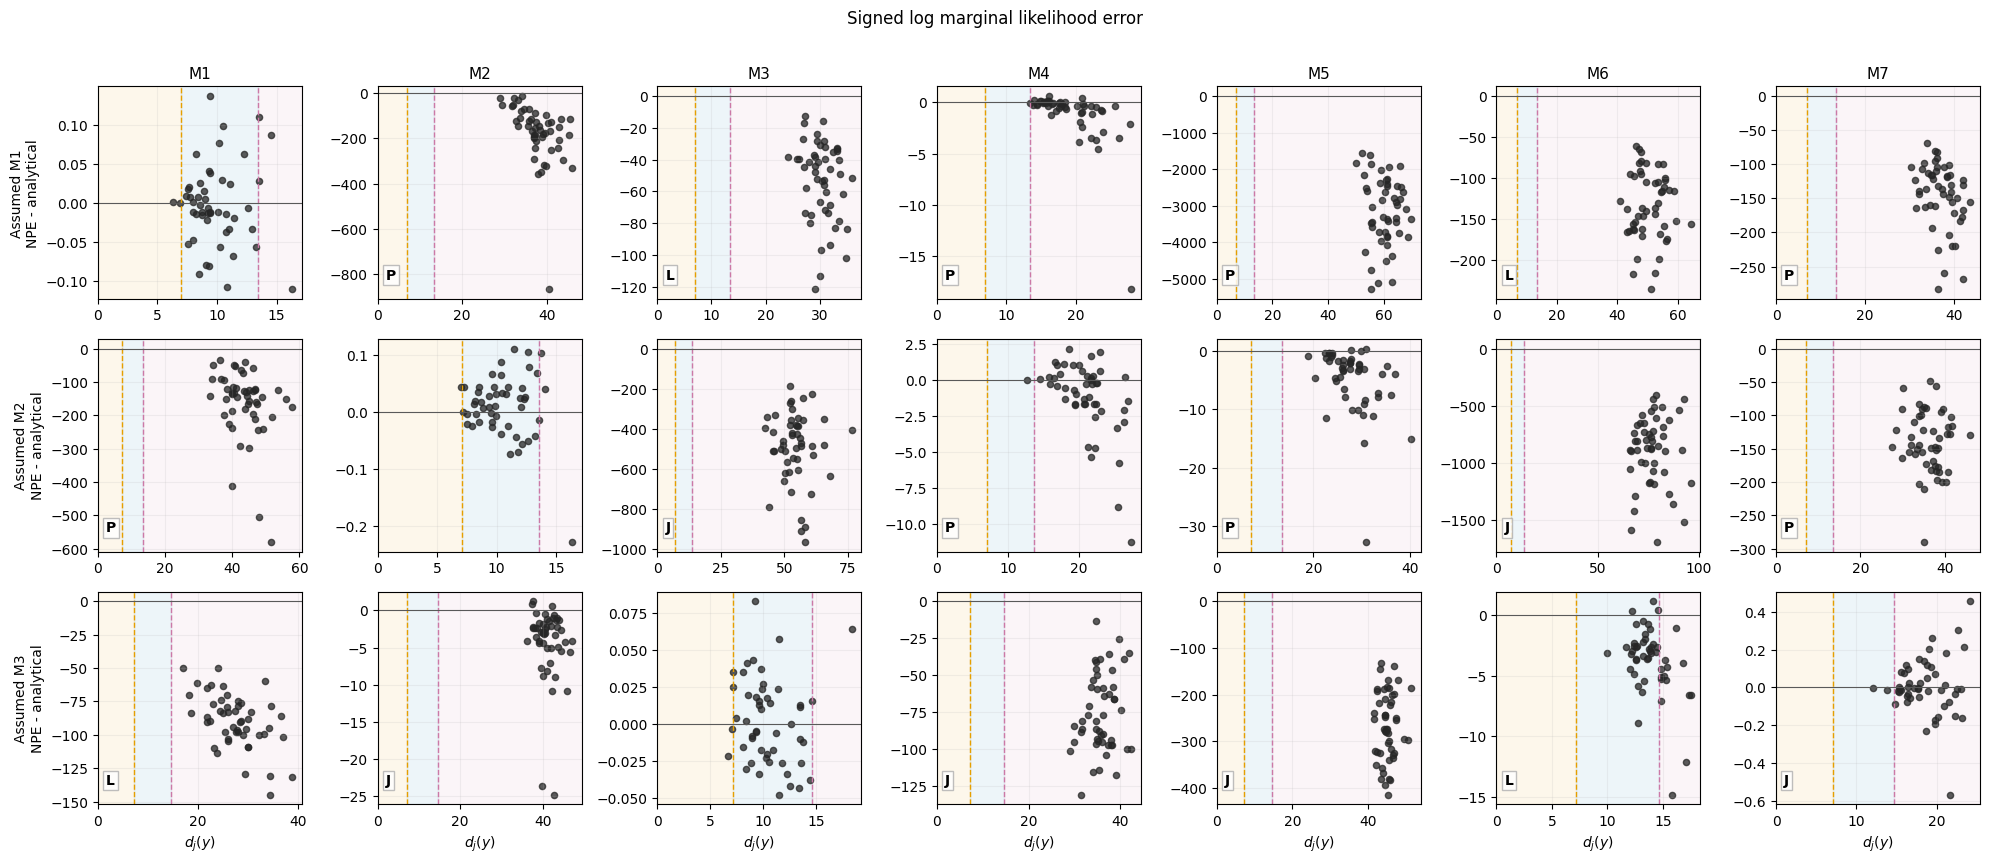

In [43]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir, sharey=False);

## PMP error plots

(<Figure size 680x510 with 1 Axes>,
 <Axes: title={'center': 'PMP RMSE vs ambiguity score'}, xlabel='$A(y)$', ylabel='PMP RMSE'>)

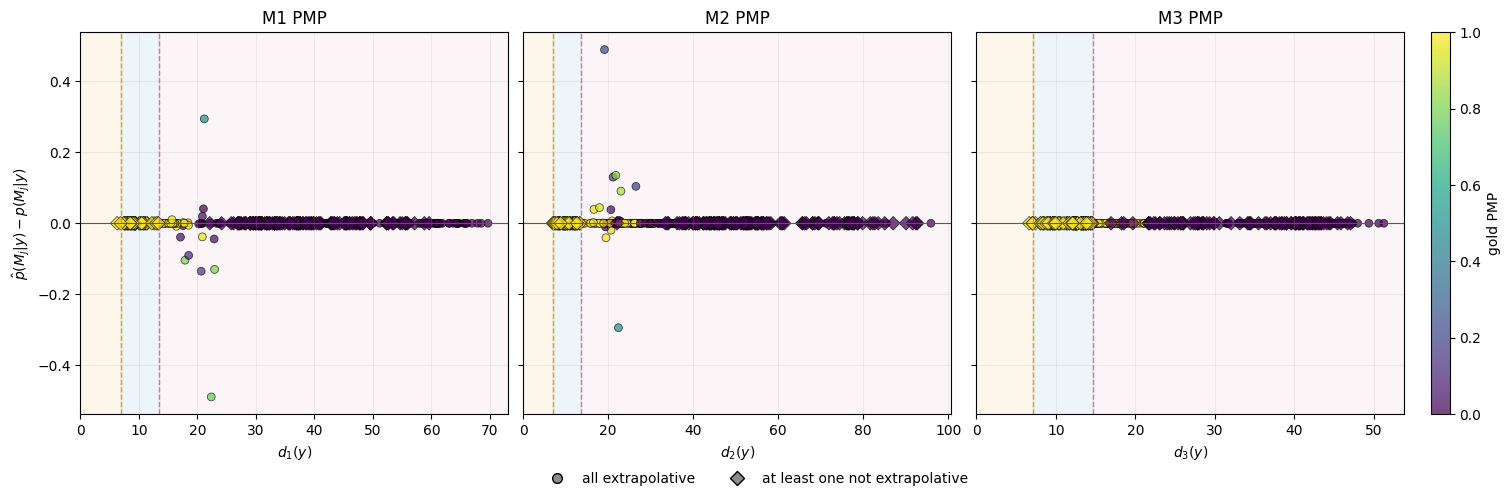

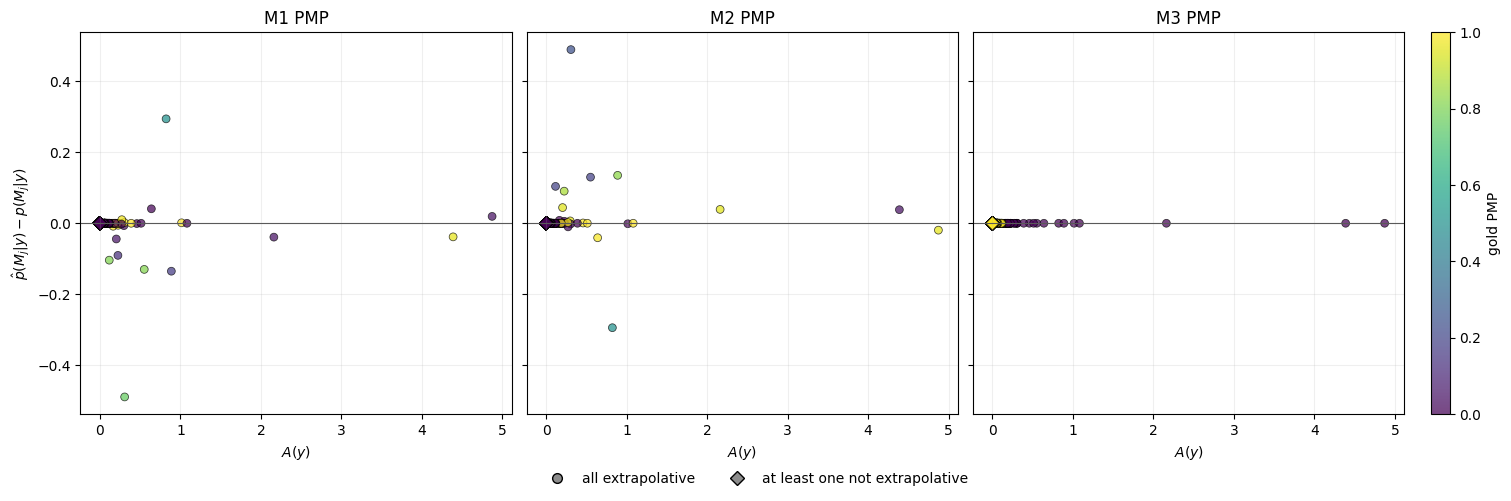

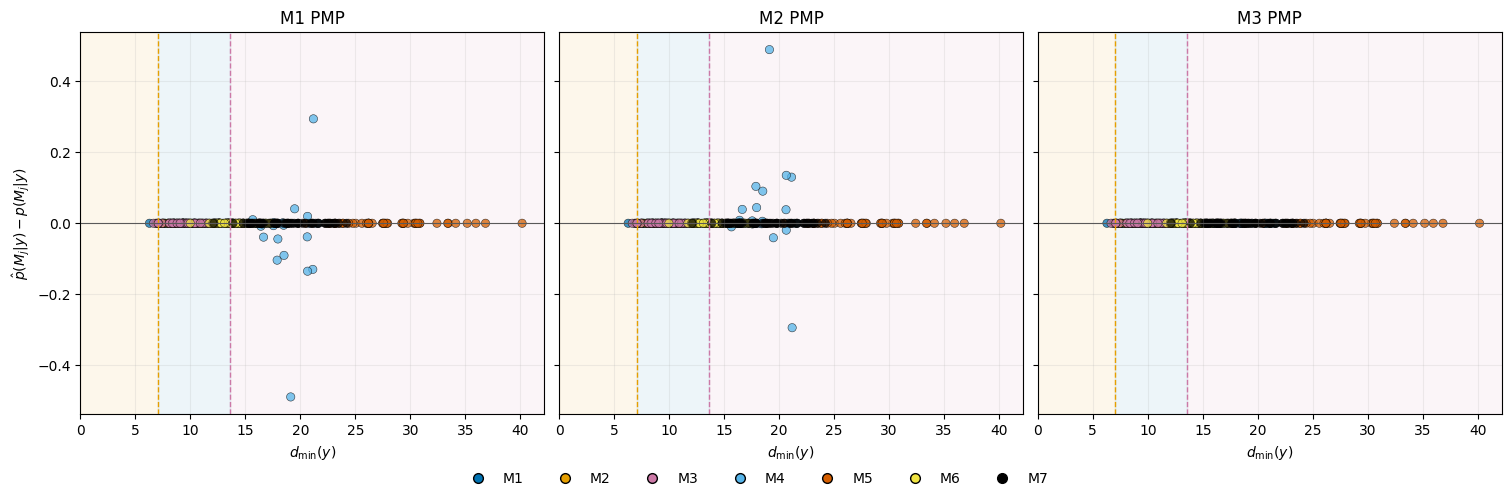

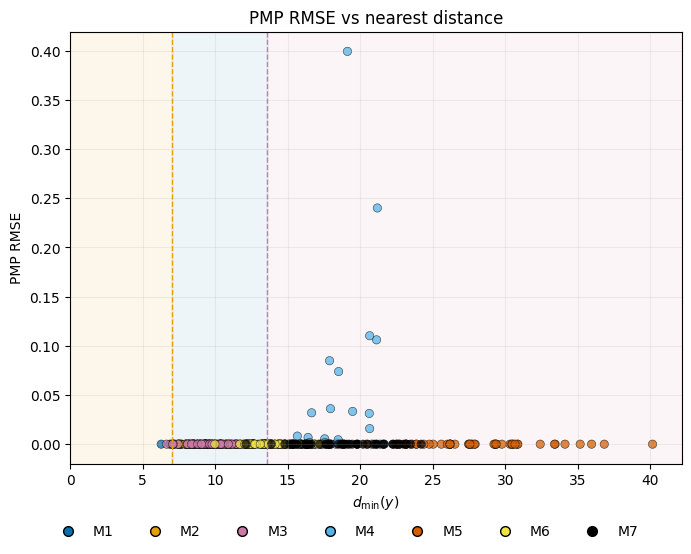

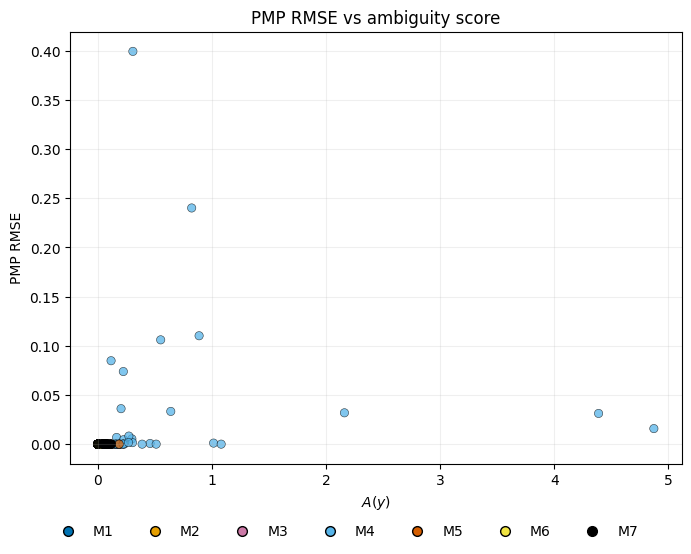

In [44]:
sd.plot_pmp_diagnostic(pmp_df, x="distance", y="signed_error", group_by="global_extrapolation", regions="assumed", estimate="npe", output_dir=figure_dir, filename="pmp_error_vs_distance_npe.png")
sd.plot_pmp_diagnostic(pmp_df, x="A", y="signed_error", group_by="global_extrapolation", estimate="npe", output_dir=figure_dir, filename="ambiguity_vs_pmp_error_npe.png")
sd.plot_pmp_diagnostic(pmp_df, x="d_min", y="signed_error", group_by="source_model", regions="nearest", estimate="npe", output_dir=figure_dir, filename="pmp_error_vs_d_min_npe.png")
sd.plot_pmp_diagnostic(pmp_df, x="d_min", y="rmse", group_by="source_model", regions="nearest", estimate="npe", output_dir=figure_dir, filename="pmp_rmse_vs_d_min_npe.png", title="PMP RMSE vs nearest distance")
sd.plot_pmp_diagnostic(pmp_df, x="A", y="rmse", group_by="source_model", estimate="npe", output_dir=figure_dir, filename="pmp_rmse_vs_A_npe.png", title="PMP RMSE vs ambiguity score")


In [45]:
# print(pmp_df[pmp_df["source_model"]=="m4"].columns)

In [46]:
# cols = ["d_m1", "d_m2","ambiguity_score","signed_pmp_error_direct_m2"]

# print(
#     pmp_df.loc[pmp_df["source_model"] == "m4", cols].round(5)
# )

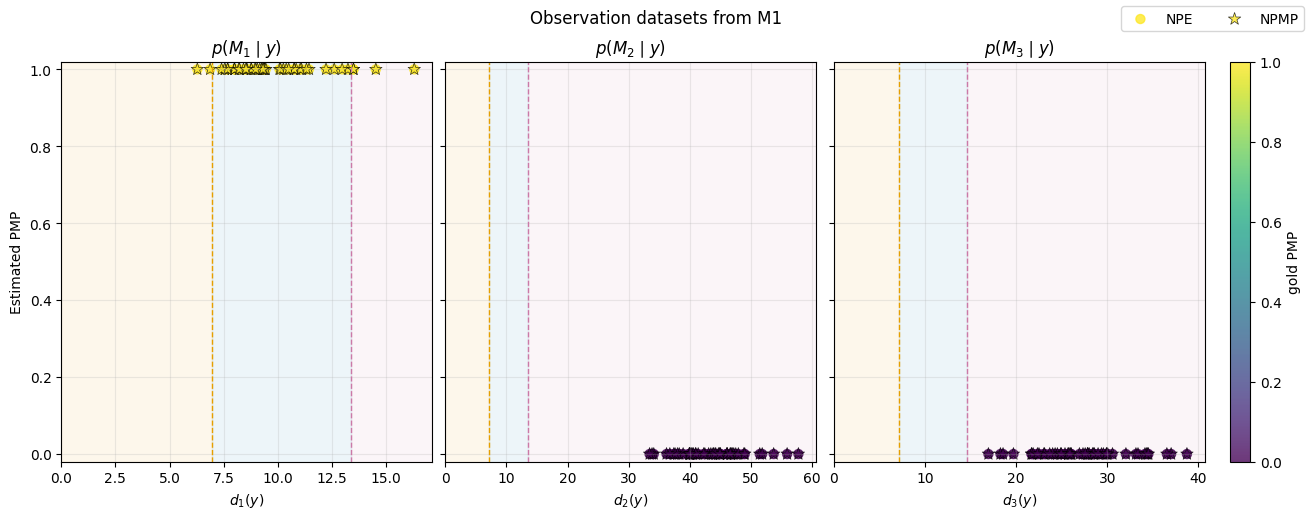

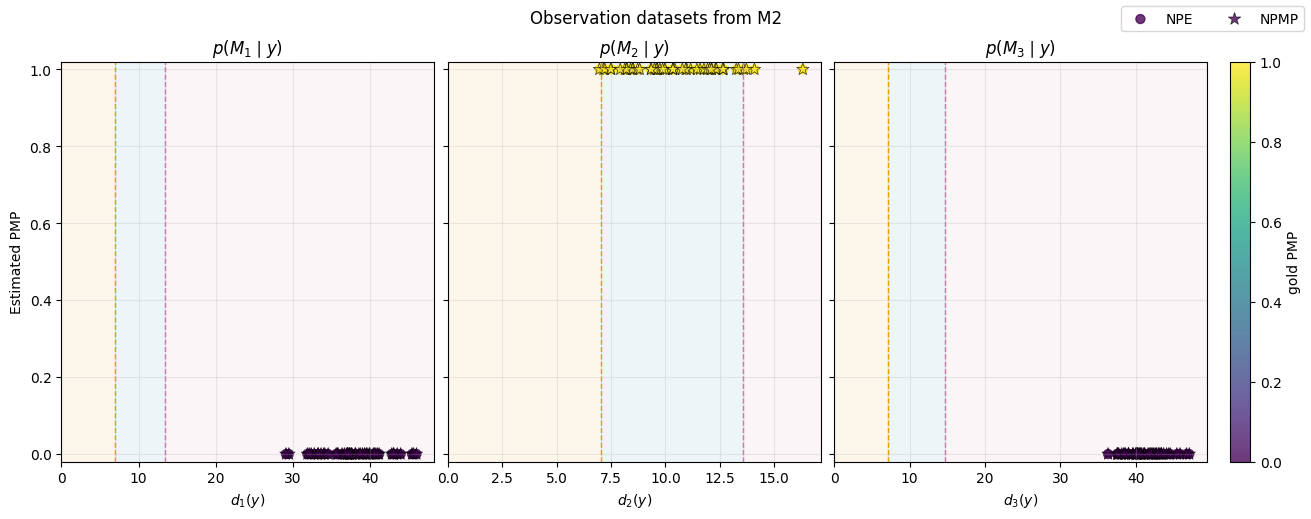

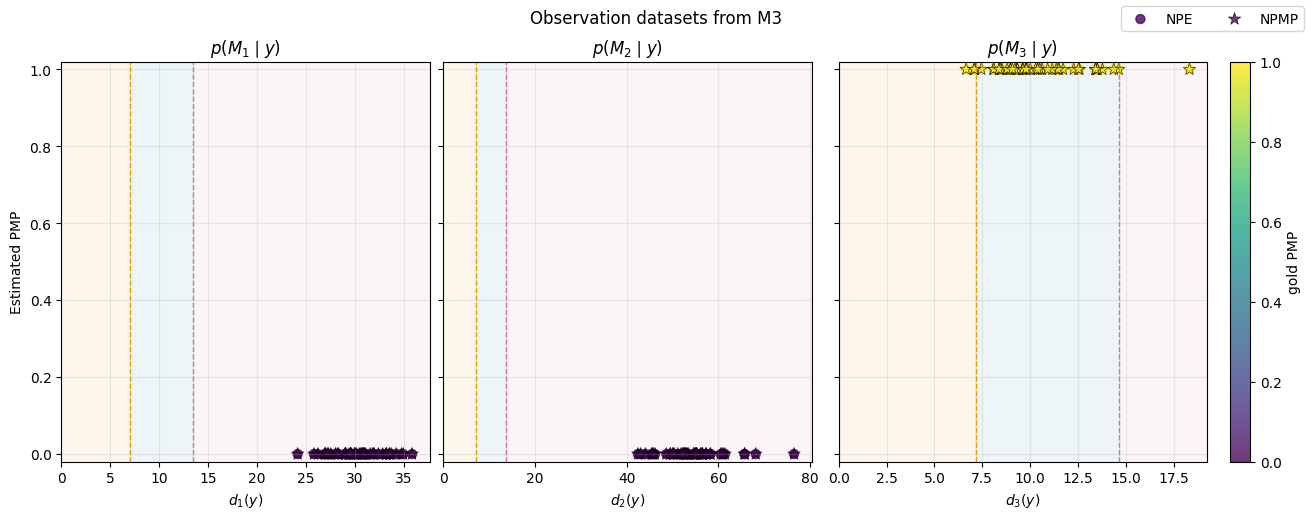

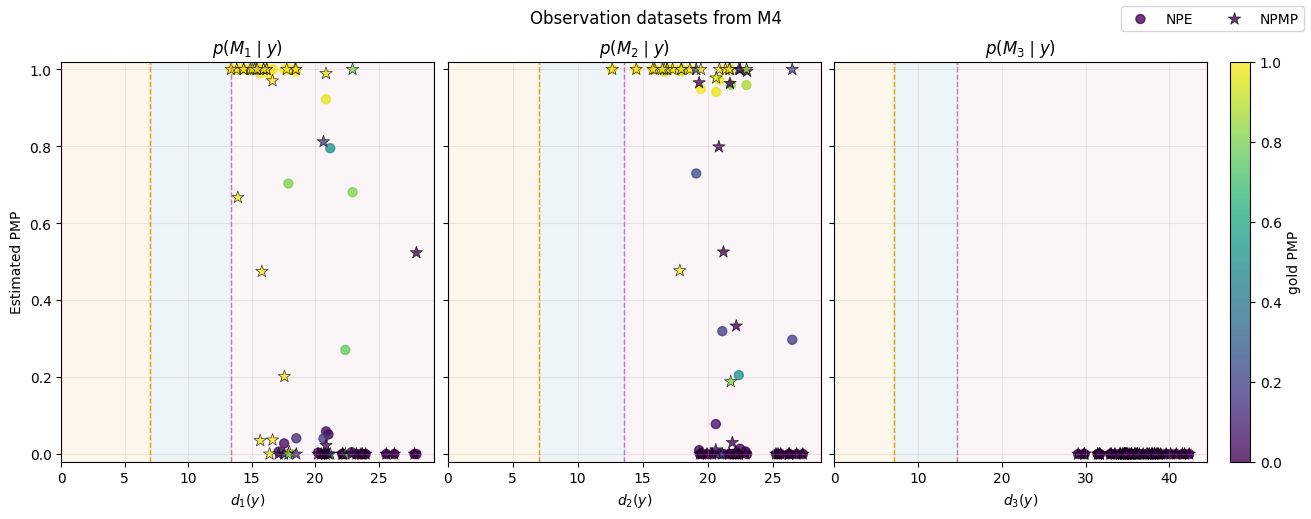

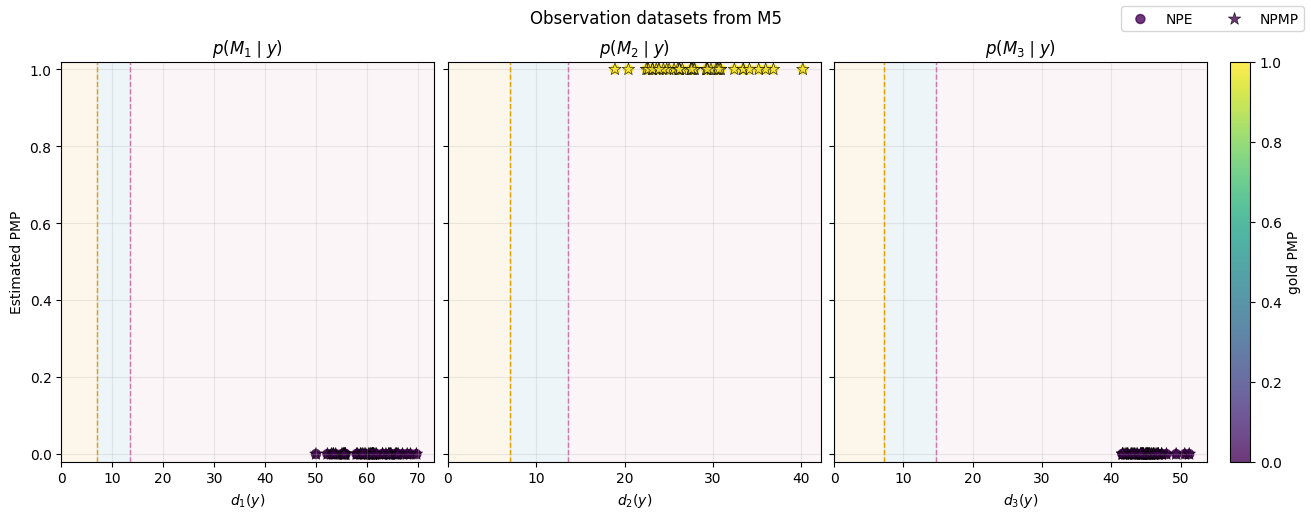

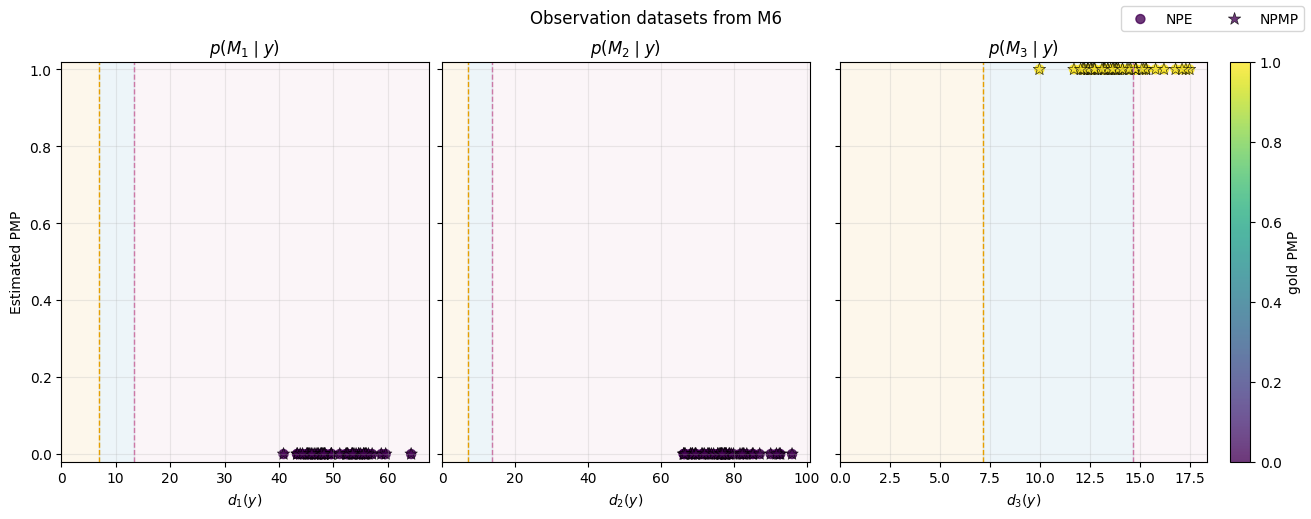

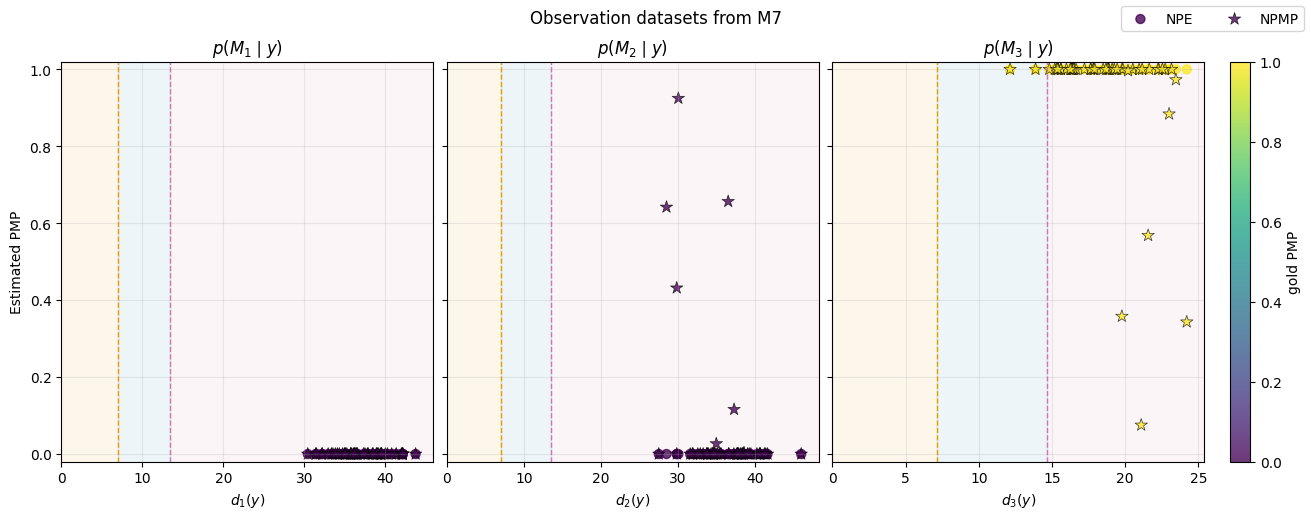

In [47]:
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source, output_dir=figure_dir)

## Inspect dynamic regimes

In [48]:
cols = [
    "source_model", "id", "d_m1", "regime_m1", "d_m2", "regime_m2", "d_m3", "regime_m3",
    "at_least_one_not_extrapolative", "ambiguity_score", "pmp_l1_error_npe",
]
pmp_df[cols].head(20).round(3)

,source_model,id,d_m1,regime_m1,d_m2,regime_m2,d_m3,regime_m3,at_least_one_not_extrapolative,ambiguity_score,pmp_l1_error_npe
0,m1,0,12.608,in_distribution,57.820,extrapolation,28.015,extrapolation,True,0.0,0.0
1,m1,1,9.260,in_distribution,51.488,extrapolation,29.356,extrapolation,True,0.0,0.0
2,m1,2,11.443,in_distribution,51.893,extrapolation,33.141,extrapolation,True,0.0,0.0
3,m1,3,10.079,in_distribution,47.044,extrapolation,28.384,extrapolation,True,0.0,0.0
4,m1,4,7.988,in_distribution,47.234,extrapolation,27.854,extrapolation,True,0.0,0.0
5,m1,5,9.416,in_distribution,46.154,extrapolation,26.038,extrapolation,True,0.0,0.0
6,m1,6,9.380,in_distribution,43.856,extrapolation,28.579,extrapolation,True,0.0,0.0
7,m1,7,9.055,in_distribution,43.112,extrapolation,23.045,extrapolation,True,0.0,0.0
8,m1,8,7.694,in_distribution,40.543,extrapolation,21.708,extrapolation,True,0.0,0.0
9,m1,9,7.557,in_distribution,43.477,extrapolation,24.273,extrapolation,True,0.0,0.0


In [49]:
print(result_dir)
print(result_dir / "logml_distance_frame.csv")
print(result_dir / "pmp_ambiguity_frame.csv")
print(figure_dir / "signed_logml_error_grid.png")
print(figure_dir / "logml_error_vs_distance_source.png")
print(figure_dir / "logml_error_vs_distance_gold_logml.png")
print(figure_dir / "pmp_error_vs_distance_npe.png")
print(figure_dir / "ambiguity_vs_pmp_error_npe.png")
print(figure_dir / "pmp_error_vs_d_min_npe.png")
print(figure_dir / "pmp_error_vs_A_all_extrapolative_npe.png")
print(figure_dir / "paired_min_distances_npe_m1.png")
print(figure_dir / "pmp_estimates_vs_distance_m1.png")

/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood
/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood/logml_distance_frame.csv
/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood/pmp_ambiguity_frame.csv
/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood/figures/signed_logml_error_grid.png
/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood/figures/logml_error_vs_distance_source.png
/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood/figures/logml_error_vs_distance_gold_logml.png
/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood/figures/pmp_error_vs_distance_npe.png
/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/m1_m7_ood/figures/ambiguity_vs_pmp_error_npe.png
/Users/yimin